Kent Lin Chan

20202132

Se usó python 3.14.2

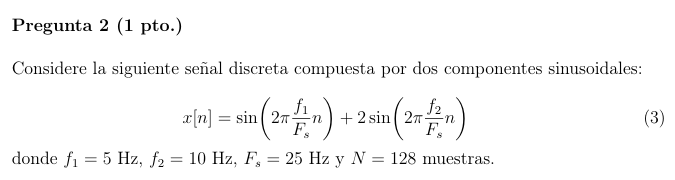

In [58]:
import matplotlib.pyplot as plt
import numpy as np
from math import *

In [59]:
f1 = 5   # Hz
f2 = 10  # Hz
Fs = 25  # Hz
N = 128  # muestras

a) Implemente la señal x[n] y grafíquela en el dominio del tiempo discreto usando un gráfico de tipo stem

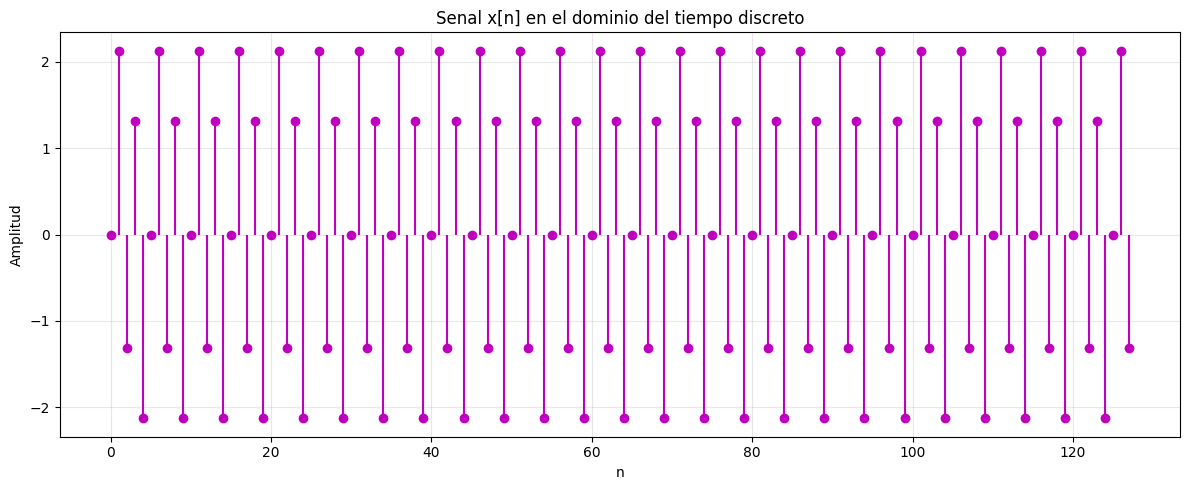

In [60]:
n = np.arange(N)

x_n = np.sin(2 * pi * (f1 / Fs) * n) + 2 * np.sin(2 * pi * (f2 / Fs) * n)

plt.figure(figsize=(12, 5))
plt.stem(n, x_n, linefmt='m-', markerfmt='mo', basefmt=' ')
plt.title('Senal x[n] en el dominio del tiempo discreto')
plt.xlabel('n')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

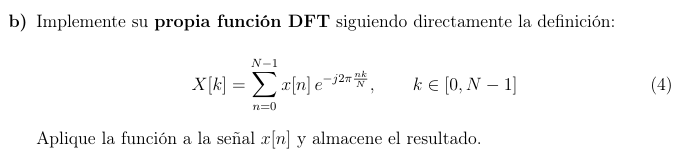

In [61]:
def mi_dft(x):
    """Calcula la DFT"""
    N = len(x)
    X = np.zeros(N, dtype=complex)
    
    for k in range(N):
        suma = 0
        for n in range(N):
            suma += x[n] * np.exp(-1j * 2 * pi * n * k / N)
        X[k] = suma
    
    return X

X_k = mi_dft(x_n)
print(X_k)

[ 8.12299241e-01+0.00000000e+00j  8.14622859e-01-4.90741839e-03j
  8.21635047e-01-9.68645230e-03j  8.33461691e-01-1.42037826e-02j
  8.50319071e-01-1.83158824e-02j  8.72524170e-01-2.18630287e-02j
  9.00510388e-01-2.46621356e-02j  9.34850202e-01-2.64978014e-02j
  9.76287091e-01-2.71107228e-02j  1.02578032e+00-2.61822535e-02j
  1.08456802e+00-2.33132821e-02j  1.15425717e+00-1.79946198e-02j
  1.23695403e+00-9.56445103e-03j  1.33545737e+00+2.85441305e-03j
  1.45355225e+00+2.04497404e-02j  1.59647047e+00+4.48690569e-02j
  1.77163924e+00+7.84622414e-02j  1.98995239e+00+1.24693677e-01j
  2.26804532e+00+1.88880261e-01j  2.63263788e+00+2.79601063e-01j
  3.12953023e+00+4.11618424e-01j  3.84433153e+00+6.12610890e-01j
  4.95773513e+00+9.41130464e-01j  6.92834919e+00+1.54600449e+00j
  1.13611360e+01+2.94850450e+00j  3.05602229e+01+9.14623754e+00j
 -4.62104089e+01-1.58413966e+01j -1.32977426e+01-5.19401750e+00j
 -7.80348601e+00-3.45906393e+00j -5.53294926e+00-2.77566979e+00j
 -4.28634972e+00-2.429635

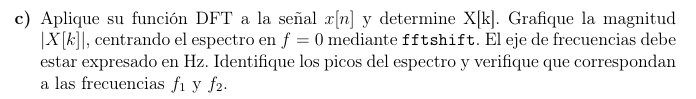

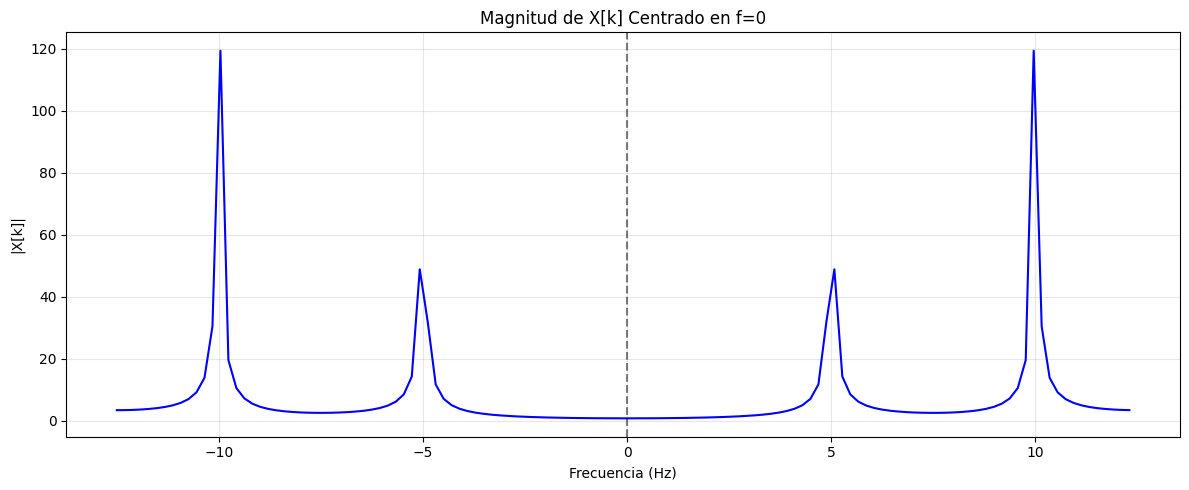


Picos del espectro (frecuencias identificadas):
  Frecuencia: -9.96 Hz, Magnitud: 119.29
  Frecuencia: -5.08 Hz, Magnitud: 48.85
  Frecuencia: 5.08 Hz, Magnitud: 48.85
  Frecuencia: 9.96 Hz, Magnitud: 119.29


In [62]:
magnitud = np.abs(X_k)

magnitud_shift = np.fft.fftshift(magnitud)


frecuencias = np.fft.fftfreq(N, d=1/Fs)
frecuencias_shift = np.fft.fftshift(frecuencias)  # Frecuencias centradas en 0

plt.figure(figsize=(12, 5))
plt.plot(frecuencias_shift, magnitud_shift, 'b-', linewidth=1.5)
plt.title('Magnitud de X[k] Centrado en f=0')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X[k]|')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

picos_idx = []
for i in range(1, len(magnitud_shift) - 1):
    if magnitud_shift[i] > magnitud_shift[i-1] and magnitud_shift[i] > magnitud_shift[i+1]:
        if magnitud_shift[i] > 0.1 * max(magnitud_shift):
            picos_idx.append(i)

print("\nPicos del espectro (frecuencias identificadas):")
for idx in picos_idx[:5]: # Mostrar solo los primeros 5 picos
    freq = frecuencias_shift[idx]
    mag = magnitud_shift[idx]
    print(f"  Frecuencia: {freq:.2f} Hz, Magnitud: {mag:.2f}")

Los picos del espectro son cercanas a las frecuencias de 5Hz y 10Hz, por lo que se puede concluir que las amplitudes de los picos son casi idénticos.

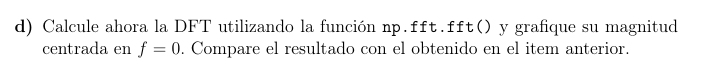

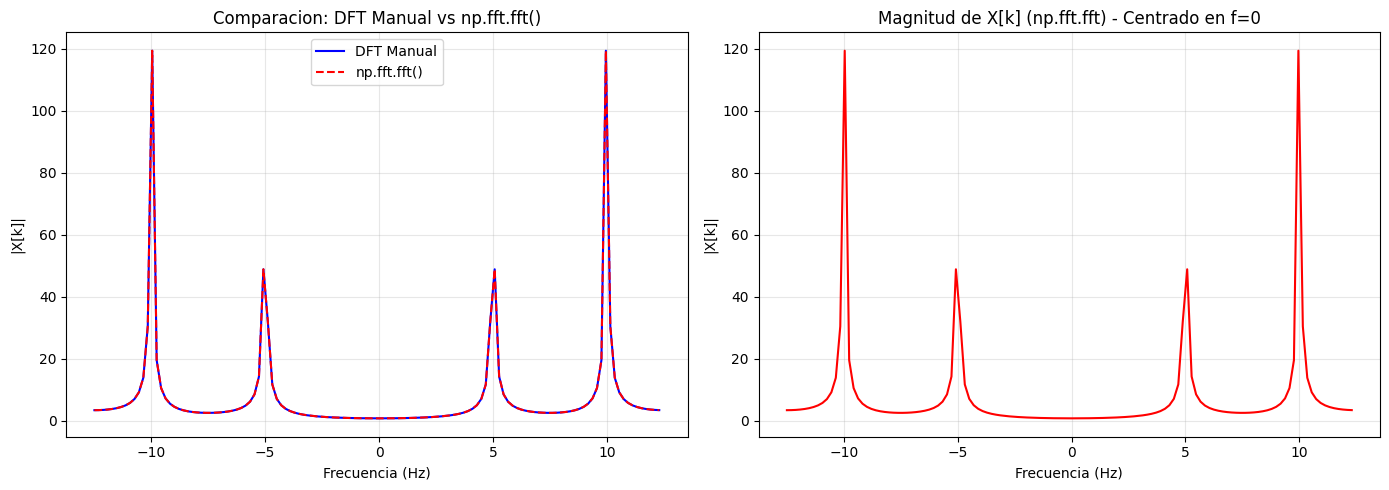

In [63]:
X_k_np = np.fft.fft(x_n)

magnitud_np = np.abs(X_k_np)

magnitud_np_shift = np.fft.fftshift(magnitud_np)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(frecuencias_shift, magnitud_shift, 'b-', linewidth=1.5, label='DFT Manual')
plt.plot(frecuencias_shift, magnitud_np_shift, 'r--', linewidth=1.5, label='np.fft.fft()')
plt.title('Comparacion: DFT Manual vs np.fft.fft()')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X[k]|')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(frecuencias_shift, magnitud_np_shift, 'r-', linewidth=1.5)
plt.title('Magnitud de X[k] (np.fft.fft) - Centrado en f=0')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('|X[k]|')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [64]:
diferencia = np.max(np.abs(magnitud_shift - magnitud_np_shift))

print(diferencia)

1.2009282457370318e-12


Se evidencia que la gráfica es parecida a lo hallado manualmente, con una diferencia de casi 0 en las amplitudes, lo que indica que el método de la DFT es consistente con el cálculo manual.